# LEGACY — DO NOT USE FOR FINAL METRICS
The multi-stage experiment derives its target from MMSE while retaining MMSE
as an input feature. Those results contain target leakage and are preserved
only as historical work.

In [1]:
import pandas as pd
data = pd.read_csv(r'C:\Users\mayank manjhi\Downloads\list_projects\Alzheimers-Disease-Prediction-main\alzheimers_disease_data.csv')

In [2]:
## Explore Data

In [3]:
data.head()


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [4]:
data.columns


Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

In [5]:
data.shape


(2149, 35)

In [6]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [7]:
data.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [8]:
data.describe()


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
data.isnull().sum()


PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

In [10]:
data.duplicated().sum()


np.int64(0)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')

In [12]:
## Data Analysis

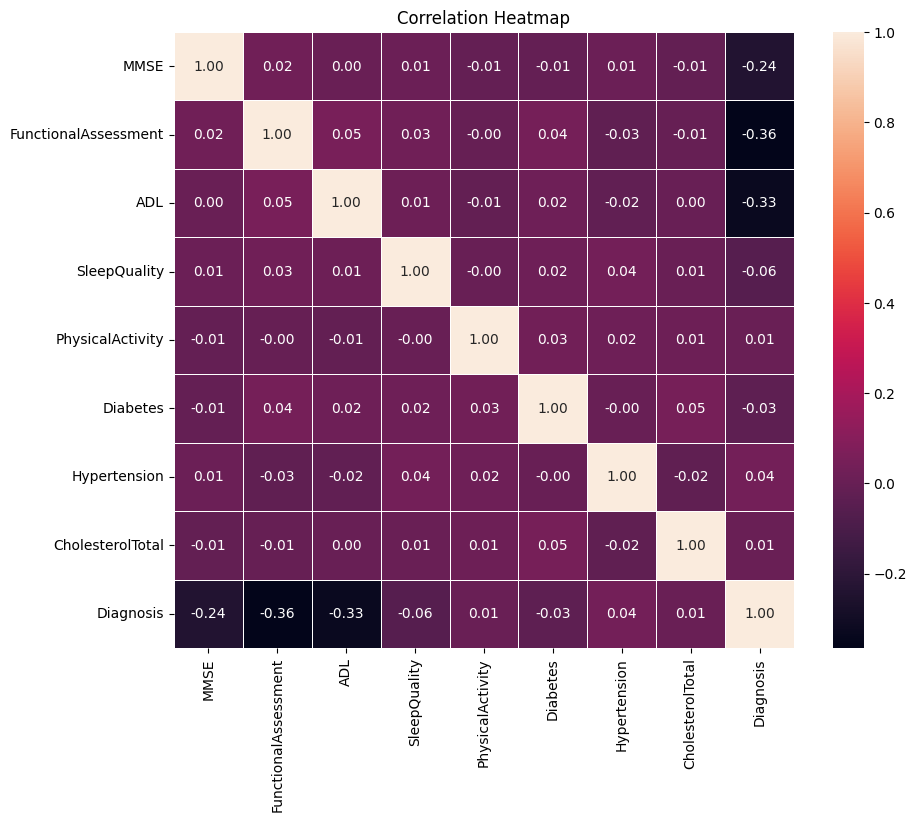

In [13]:
corr_columns = [   'MMSE', 'FunctionalAssessment', 'ADL', 'SleepQuality', 'PhysicalActivity','Diabetes', 'Hypertension', 'CholesterolTotal','Diagnosis']
corr = data[corr_columns].corr()
sns.set_palette("husl")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

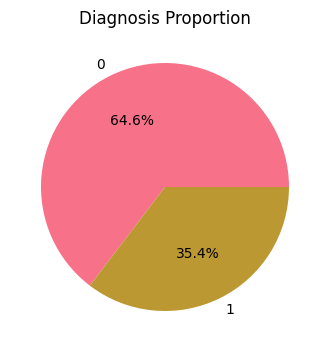

In [14]:
sns.set_palette("husl")
diagnosis_counts = data['Diagnosis'].value_counts()
plt.figure(figsize=(4, 6))
plt.pie(diagnosis_counts, labels=diagnosis_counts.index, autopct='%1.1f%%')
plt.title('Diagnosis Proportion')
plt.show()

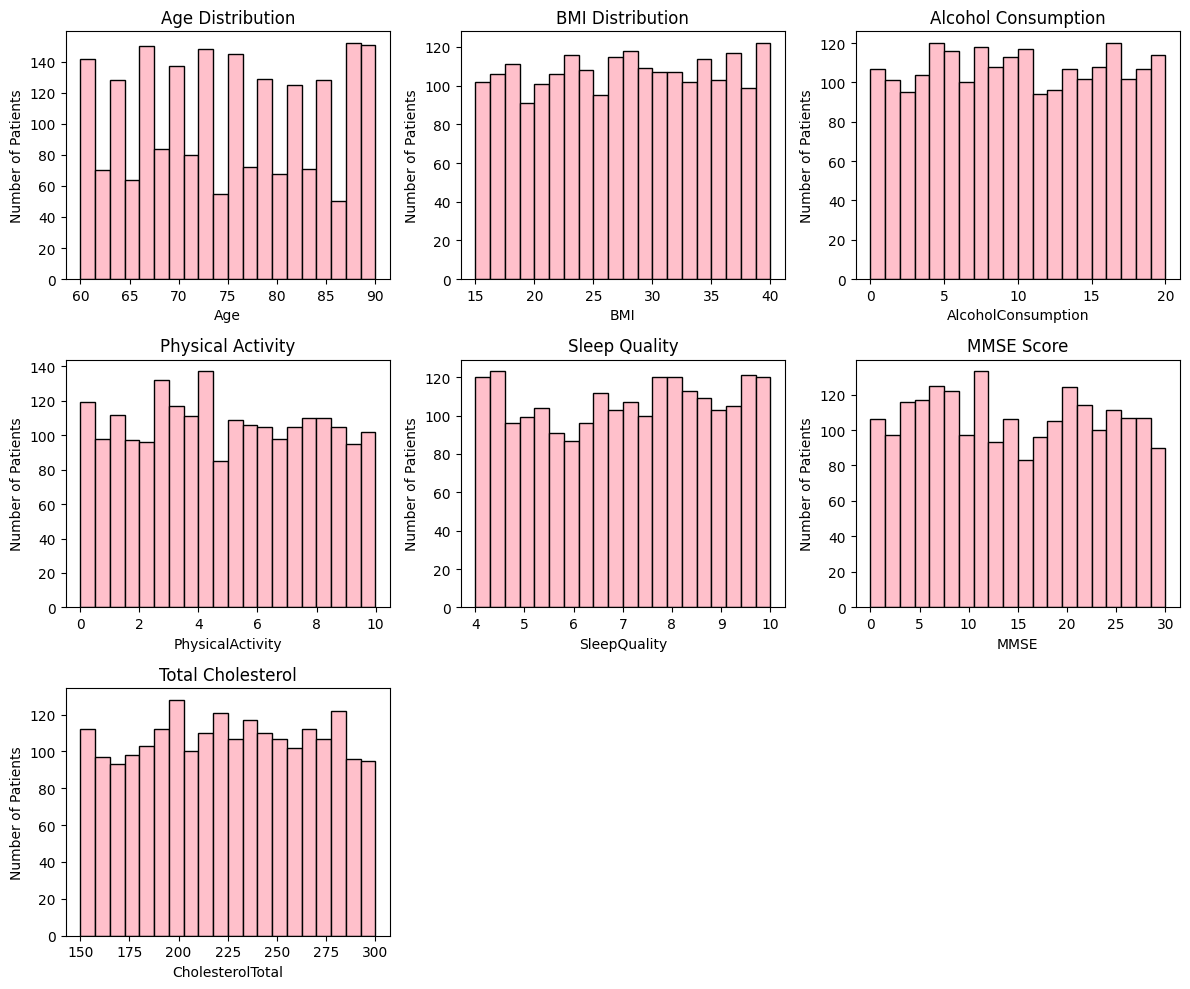

In [15]:

columns = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'SleepQuality', 'MMSE', 'CholesterolTotal']
titles = {
    'Age': 'Age Distribution',
    'BMI': 'BMI Distribution',
    'AlcoholConsumption': 'Alcohol Consumption',
    'PhysicalActivity': 'Physical Activity',
    'SleepQuality': 'Sleep Quality',
    'MMSE': 'MMSE Score',
    'CholesterolTotal': 'Total Cholesterol'
}
sns.set_palette("husl")
plt.figure(figsize=(12, 10))
for i, col in enumerate(columns):
    plt.subplot(3, 3, i + 1)
    plt.hist(data[col], bins=20, color='pink', edgecolor='black')
    plt.title(titles[col])
    plt.xlabel(col)
    plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

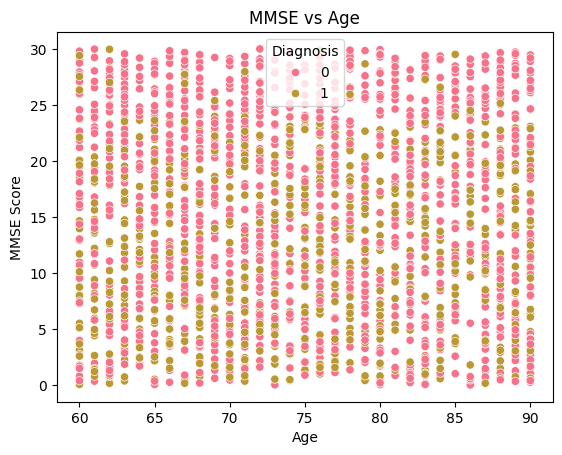

In [16]:
sns.set_palette("husl")
sns.scatterplot(data=data, x='Age', y='MMSE', hue='Diagnosis')
plt.title('MMSE vs Age')
plt.xlabel('Age')
plt.ylabel('MMSE Score')
plt.show()

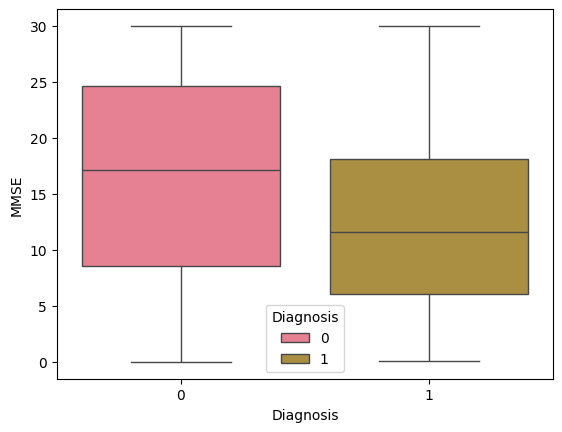

In [17]:
sns.set_palette("husl")
sns.boxplot(data=data, x='Diagnosis', y='MMSE', hue='Diagnosis')
plt.show()

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [19]:
## Modeling and Evaluation

In [20]:
X=data.drop(["DoctorInCharge","PatientID","Diagnosis"],axis=1)
y=data["Diagnosis"]

In [21]:
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [22]:
def try_model(model):
    model.fit(X_train_bin, y_train_bin)
    y_pred = model.predict(X_test_bin)
    print(classification_report(y_test_bin, y_pred))
    plt.figure(figsize=(4, 2))
    sns.set_palette("husl")
    sns.heatmap(confusion_matrix(y_test_bin, y_pred),annot=True,fmt='d',linewidths=0.5,linecolor='white')

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       278
           1       0.75      0.71      0.73       152

    accuracy                           0.81       430
   macro avg       0.80      0.79      0.79       430
weighted avg       0.81      0.81      0.81       430



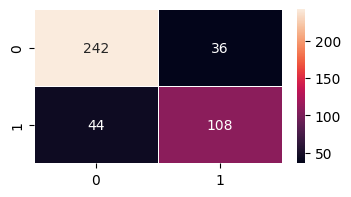

In [23]:
LogisticRegressionModel = LogisticRegression(solver='liblinear', max_iter=1000)
try_model(LogisticRegressionModel)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       278
           1       0.94      0.88      0.91       152

    accuracy                           0.94       430
   macro avg       0.94      0.92      0.93       430
weighted avg       0.94      0.94      0.94       430



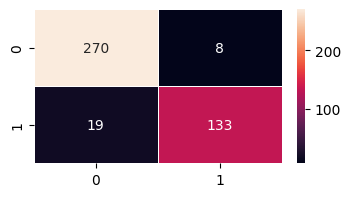

In [24]:
RandomForestClassifierModel=RandomForestClassifier()
try_model(RandomForestClassifierModel)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       278
           1       0.93      0.92      0.92       152

    accuracy                           0.95       430
   macro avg       0.94      0.94      0.94       430
weighted avg       0.95      0.95      0.95       430



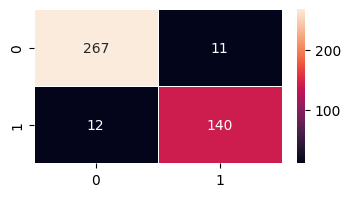

In [25]:
GradientBoostingClassifierModel=GradientBoostingClassifier()
try_model(GradientBoostingClassifierModel)

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       278
           1       0.93      0.91      0.92       152

    accuracy                           0.94       430
   macro avg       0.94      0.94      0.94       430
weighted avg       0.94      0.94      0.94       430



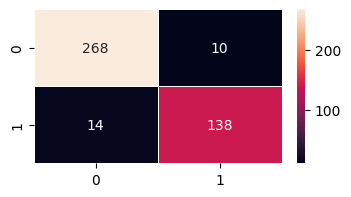

In [26]:
XGBClassifierModel = XGBClassifier(n_estimators=200,random_state=42)
try_model(XGBClassifierModel)

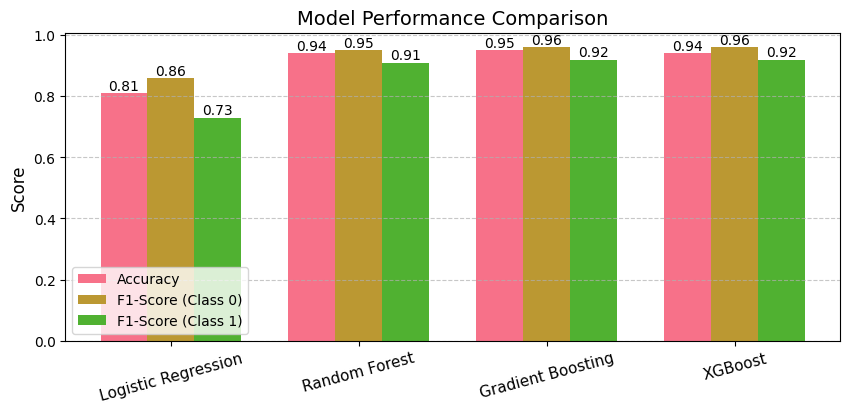

In [27]:
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']
accuracy = [0.81, 0.94, 0.95, 0.94]
f1_class_0 = [0.86, 0.95, 0.96, 0.96]
f1_class_1 = [0.73, 0.91, 0.92, 0.92]
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width, accuracy, width, label='Accuracy')
ax.bar(x, f1_class_0, width, label='F1-Score (Class 0)')
ax.bar(x + width, f1_class_1, width, label='F1-Score (Class 1)')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, fontsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(models)):
    ax.text(x[i] - width, accuracy[i] + 0.01, f"{accuracy[i]:.2f}", ha='center', fontsize=10)
    ax.text(x[i], f1_class_0[i] + 0.01, f"{f1_class_0[i]:.2f}", ha='center', fontsize=10)
    ax.text(x[i] + width, f1_class_1[i] + 0.01, f"{f1_class_1[i]:.2f}", ha='center', fontsize=10)
plt.show()

In [28]:
model_binary = XGBClassifier(n_estimators=200, random_state=42)
model_binary.fit(X_train_bin, y_train_bin)

# After training
import pickle
pickle.dump(model_binary, open("model_binary.pkl", "wb"))


In [29]:
def classify_multistage(score):
    if score >= 26:
        return "Non Demented"
    elif 21 <= score < 26:
        return "Very Mild Demented"
    elif 11 <= score < 21:
        return "Mild Demented"
    else:
        return "Moderate Demented"

# Create new multi-class column
data["Diagnosis_Multi"] = data["MMSE"].apply(classify_multistage)

print(data["Diagnosis_Multi"].value_counts())


Diagnosis_Multi
Moderate Demented     830
Mild Demented         690
Very Mild Demented    366
Non Demented          263
Name: count, dtype: int64


In [30]:
from sklearn.preprocessing import LabelEncoder

X = data.drop(["DoctorInCharge", "PatientID", "Diagnosis"], axis=1)
y = data["Diagnosis"]

# --- Encode categorical columns in X ---
for col in X.columns:
    if X[col].dtype == 'object':   # If column is string/categorical
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# --- Encode target variable ---
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

# --- Train/Test Split ---
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y_encoded, stratify=y_encoded, test_size=0.2, random_state=42
)

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(objective='multi:softmax', num_class=len(le_y.classes_), random_state=42),
    "SVM": SVC(kernel='rbf', C=1, gamma='scale')
}


=== Logistic Regression ===
Accuracy: 0.8977
                    precision    recall  f1-score   support

     Mild Demented       0.89      0.89      0.89       138
 Moderate Demented       0.98      0.98      0.98       166
      Non Demented       0.88      0.85      0.87        53
Very Mild Demented       0.75      0.77      0.76        73

          accuracy                           0.90       430
         macro avg       0.87      0.87      0.87       430
      weighted avg       0.90      0.90      0.90       430


=== Random Forest ===
Accuracy: 0.9953
                    precision    recall  f1-score   support

     Mild Demented       1.00      1.00      1.00       138
 Moderate Demented       1.00      1.00      1.00       166
      Non Demented       1.00      0.96      0.98        53
Very Mild Demented       0.97      1.00      0.99        73

          accuracy                           1.00       430
         macro avg       0.99      0.99      0.99       430
      wei

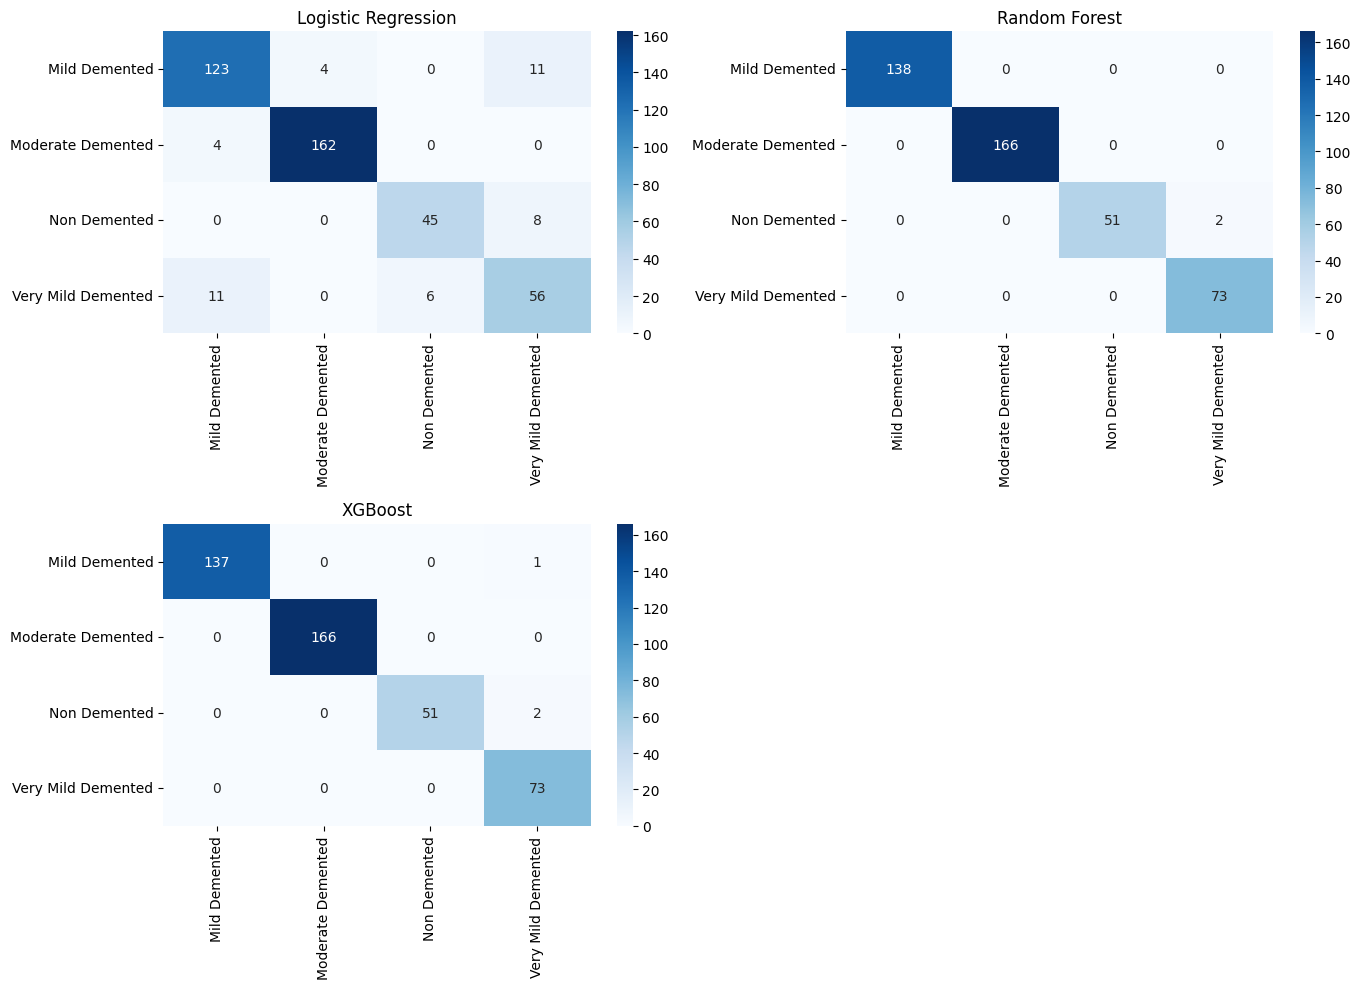


Model Comparison:
                  Model  Accuracy
0  Logistic Regression  0.897674
1        Random Forest  0.995349
2              XGBoost  0.993023


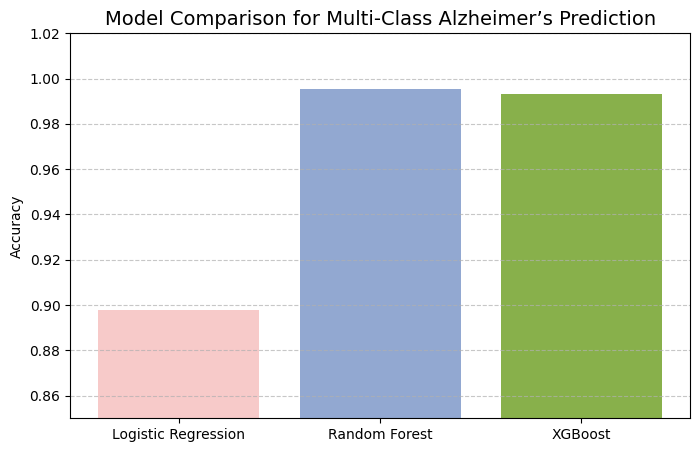

In [32]:
# Label encode the target
le_y = LabelEncoder()
y_multi = le_y.fit_transform(data["Diagnosis_Multi"])  # 4 classes

# Encode categorical features
X = pd.get_dummies(
    data.drop(["DoctorInCharge", "PatientID", "Diagnosis", "Diagnosis_Multi"], axis=1),
    drop_first=True
)

# Split data
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

# Define models
models = {
    "Logistic Regression": LogisticRegression(
        multi_class="multinomial", solver="lbfgs", max_iter=1000
    ),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        objective='multi:softmax', num_class=4, eval_metric='mlogloss', random_state=42
    ),
}

# Train, evaluate, and plot confusion matrices
results = []
plt.figure(figsize=(14, 10))

for i, (name, model) in enumerate(models.items()):
    print(f"\n=== {name} ===")
    model.fit(X_train_multi, y_train_multi)
    y_pred = model.predict(X_test_multi)
    acc = accuracy_score(y_test_multi, y_pred)
    results.append((name, acc))
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test_multi, y_pred, target_names=le_y.classes_))

    plt.subplot(2, 2, i + 1)
    sns.heatmap(
        confusion_matrix(y_test_multi, y_pred),
        annot=True, fmt='d', cmap='Blues',
        xticklabels=le_y.classes_,
        yticklabels=le_y.classes_
    )
    plt.title(name)

plt.tight_layout()
plt.show()

# Create DataFrame for results
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\nModel Comparison:\n", results_df)

# Plot accuracies dynamically
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Accuracy"],
        color=['#F7CAC9', '#92A8D1', '#88B04B'])
plt.ylim(0.85, 1.02)
plt.title("Model Comparison for Multi-Class Alzheimer’s Prediction", fontsize=14)
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [33]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(XGBClassifier(objective='multi:softmax', num_class=4, eval_metric='mlogloss'), X, y_multi, cv=5)
print("Cross-Validation Accuracy:", scores.mean())


Cross-Validation Accuracy: 0.9962758172060499


In [34]:
model_multi = GradientBoostingClassifier(random_state=42)
model_multi.fit(X_train_multi, y_train_multi)

pickle.dump(model_multi, open("model_multi.pkl", "wb"))


In [35]:
pickle.dump(le_y, open("label_encoder.pkl", "wb"))
